In [19]:
# =============================================================================
# Startup Investment Dataset – Train / Validation / Test Split
# Google Colab — runs from Google Drive
# =============================================================================
# PRE-REQUISITE:
#   Run DS22_ML_Data_Cleanup_And_EDA.ipynb first.
#   That script saves  investments_VC_clean.csv  to OUTPUT_DIR.
#   This script reads that clean file and produces:
#       train_set.csv      (70%)
#       validation_set.csv (15%)
#       test_set.csv       (15%)
# =============================================================================

# ── 0. Mount Drive & set paths ───────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

import os

# *** Edit this to match your Drive location (same folder used in EDA script) ***
OUTPUT_DIR = "/content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs"

CLEAN_DATA_PATH = f"{OUTPUT_DIR}/investments_VC_clean.csv"
TRAIN_PATH      = f"{OUTPUT_DIR}/train_set.csv"
VAL_PATH        = f"{OUTPUT_DIR}/validation_set.csv"
TEST_PATH       = f"{OUTPUT_DIR}/test_set.csv"

print(f"Reading clean data from      : {CLEAN_DATA_PATH}")
print(f"Train set will be saved      : {TRAIN_PATH}")
print(f"Validation set will be saved : {VAL_PATH}")
print(f"Test  set will be saved      : {TEST_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading clean data from      : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/investments_VC_clean.csv
Train set will be saved      : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/train_set.csv
Validation set will be saved : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/validation_set.csv
Test  set will be saved      : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/test_set.csv


In [20]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [21]:
# ── 2. Load clean dataset ─────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_DATA_PATH)

print(f"Loaded dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget variable (status_code) distribution in full dataset:")
print(df["status_code"].value_counts().sort_index())
print(f"\n  (0 = closed | 1 = operating | 2 = acquired)")

Loaded dataset shape : 48,124 rows × 32 columns

Target variable (status_code) distribution in full dataset:
status_code
0     2603
1    41829
2     3692
Name: count, dtype: int64

  (0 = closed | 1 = operating | 2 = acquired)


In [22]:
# ── 3. Stratified Train / Validation / Test Split (70 / 15 / 15) ────────────
# We can't do a three-way split in one call, so we do it in two steps:
#   Step A: split full data → 70% train  |  30% temp
#   Step B: split temp      → 50% val    |  50% test  (= 15% / 15% of full)
# stratify is applied at both steps so class proportions are preserved
# throughout — critical for imbalanced targets.

# Step A — carve out the train set (70%)
train_set, temp_set = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["status_code"],
    shuffle=True,
)

# Step B — split the remaining 30% evenly into validation and test (15% each)
val_set, test_set = train_test_split(
    temp_set,
    test_size=0.50,
    random_state=42,
    stratify=temp_set["status_code"],
    shuffle=True,
)

print(f"Train      set : {len(train_set):,} rows  ({len(train_set)/len(df)*100:.1f}%)")
print(f"Validation set : {len(val_set):,} rows  ({len(val_set)/len(df)*100:.1f}%)")
print(f"Test       set : {len(test_set):,} rows  ({len(test_set)/len(df)*100:.1f}%)")

Train      set : 33,686 rows  (70.0%)
Validation set : 7,219 rows  (15.0%)
Test       set : 7,219 rows  (15.0%)


Class distribution (proportions):
             Full dataset  Train set  Validation set  Test set
status_code                                                   
closed             5.4100     5.4100          5.4000    5.4200
operating         86.9200    86.9200         86.9200   86.9100
acquired           7.6700     7.6700          7.6700    7.6700  (%)


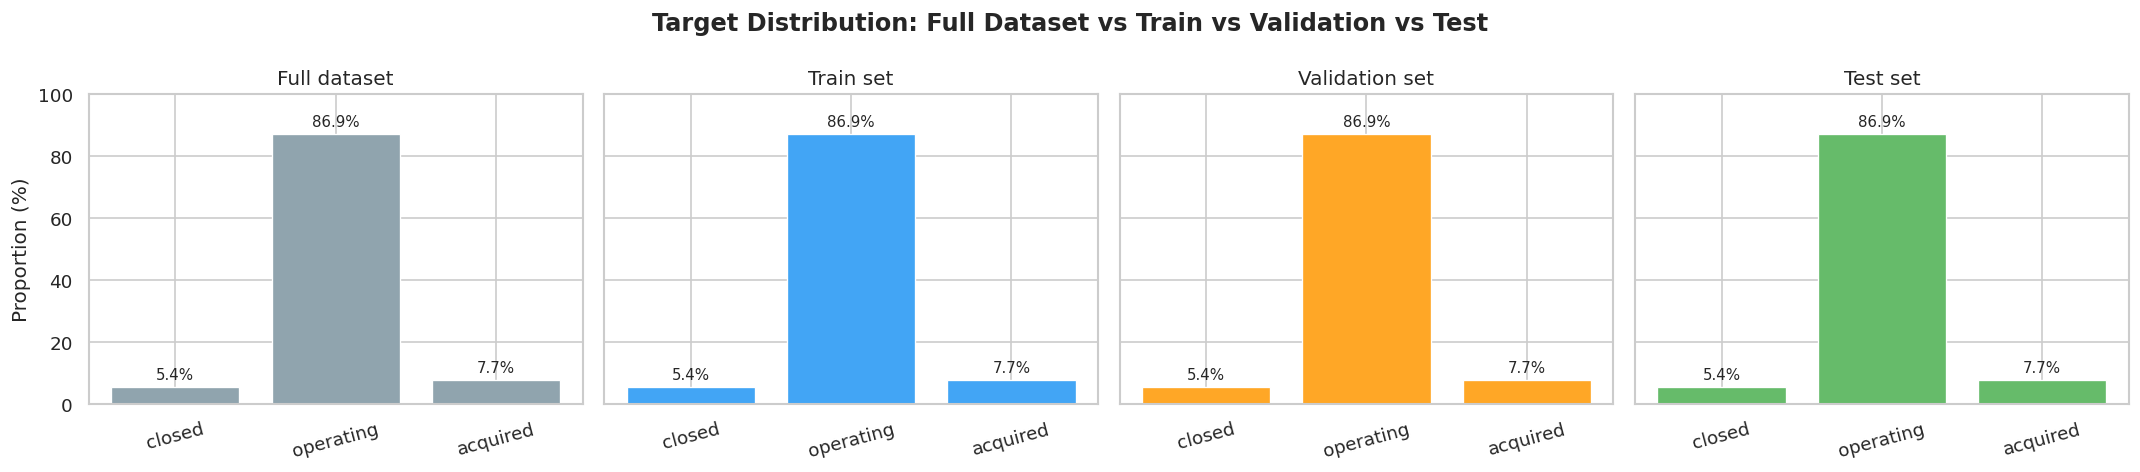


Plot saved → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/split_target_distribution.png


In [23]:
# ── 4. Verify Class Distribution is Preserved ────────────────────────────────
LABELS = {0: "closed", 1: "operating", 2: "acquired"}

full_dist  = df["status_code"].value_counts(normalize=True).sort_index().rename("Full dataset")
train_dist = train_set["status_code"].value_counts(normalize=True).sort_index().rename("Train set")
val_dist   = val_set["status_code"].value_counts(normalize=True).sort_index().rename("Validation set")
test_dist  = test_set["status_code"].value_counts(normalize=True).sort_index().rename("Test set")

dist_report = pd.concat([full_dist, train_dist, val_dist, test_dist], axis=1)
dist_report.index = dist_report.index.map(LABELS)

print("Class distribution (proportions):")
print((dist_report * 100).round(2).to_string() + "  (%)")

# ── 4.1 Visual comparison ────────────────────────────────────────────────────
COLORS = ["#90a4ae", "#42a5f5", "#ffa726", "#66bb6a"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("Target Distribution: Full Dataset vs Train vs Validation vs Test", fontweight="bold")

for ax, (col, color) in zip(axes, zip(dist_report.columns, COLORS)):
    bars = ax.bar(dist_report.index, dist_report[col] * 100,
                  color=color, edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_title(col)
    ax.set_ylabel("Proportion (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/split_target_distribution.png", bbox_inches="tight")
plt.show()
print(f"\nPlot saved → {OUTPUT_DIR}/split_target_distribution.png")

In [24]:
# ── 5. Save Train, Validation and Test Sets ──────────────────────────────────
train_set.to_csv(TRAIN_PATH, index=False)
val_set.to_csv(VAL_PATH,     index=False)
test_set.to_csv(TEST_PATH,   index=False)

print("=" * 60)
print("Split complete!")
print(f"  Train      set ({len(train_set):,} rows) → {TRAIN_PATH}")
print(f"  Validation set ({len(val_set):,} rows) → {VAL_PATH}")
print(f"  Test       set ({len(test_set):,} rows) → {TEST_PATH}")
print("=" * 60)
print("\nNext steps: fit preprocessing/imputation pipelines on the")
print("TRAIN SET only, then apply (transform) to all three sets.")

# Expose splits as named DataFrames for downstream use
train_df = train_set.copy()
val_df   = val_set.copy()
test_df  = test_set.copy()

print(f"\ntrain_df : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"val_df   : {val_df.shape[0]:,} rows × {val_df.shape[1]} columns")
print(f"test_df  : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
print("\nDisplaying train_df (scroll right for all columns):")
train_df

Split complete!
  Train      set (33,686 rows) → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/train_set.csv
  Validation set (7,219 rows) → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/validation_set.csv
  Test       set (7,219 rows) → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/test_set.csv

Next steps: fit preprocessing/imputation pipelines on the
TRAIN SET only, then apply (transform) to all three sets.

train_df : 33,686 rows × 32 columns
val_df   : 7,219 rows × 32 columns
test_df  : 7,219 rows × 32 columns

Displaying train_df (scroll right for all columns):


,market,funding_total_usd,country_code,funding_rounds,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,status_label,status_code
1398,Software,325999.0000,USA,1.0000,1.0000,1.0000,2012.0000,2013-11-26,2013-11-26,0.0000,325999.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
40838,Other,2800000.0000,Other,2.0000,3.0000,1.0000,2011.0000,2011-08-29,2012-12-17,500000.0000,2300000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2300000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
750,Other,100000.0000,Other,1.0000,5.0000,2.0000,2013.0000,2013-11-26,2013-11-26,0.0000,0.0000,0.0000,0.0000,100000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
22983,E-Commerce,10550000.0000,USA,2.0000,1.0000,1.0000,2012.0000,2013-08-29,2014-10-01,1750000.0000,8800000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8800000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
42473,Other,19300000.0000,USA,3.0000,5.0000,2.0000,2010.0000,2010-01-01,2014-02-05,0.0000,19300000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3800000.0000,15500000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,Health Care,4545754.0000,GBR,1.0000,1.0000,1.0000,2003.0000,2014-02-25,2014-02-25,0.0000,4545754.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
22805,Games,1000000.0000,Other,1.0000,1.0000,1.0000,1999.0000,2010-11-01,2010-11-01,0.0000,1000000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1000000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
43068,Analytics,500000.0000,Other,1.0000,8.0000,3.0000,2012.0000,2012-08-01,2012-08-01,500000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1
13916,Other,150000.0000,USA,2.0000,2.0000,1.0000,2008.0000,2008-12-01,2010-08-01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,150000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,operating,1


In [25]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [26]:
# Use the in-memory DataFrame from the split notebook if available,
# otherwise fall back to loading from CSV.
try:
    train = train_df.copy()
    print('Loaded from in-memory train_df DataFrame')
except NameError:
    train = pd.read_csv('train_set.csv')
    print('train_df not found in memory — loaded from train_set.csv')

print(f'\nTrain : {train.shape[0]:,} rows × {train.shape[1]} columns')

train.head()

# Verify class distribution
counts = train['status_code'].value_counts(normalize=True).sort_index()
print(f'Train: closed={counts[0]:.3f}  operating={counts[1]:.3f}  acquired={counts[2]:.3f}')

Loaded from in-memory train_df DataFrame

Train : 33,686 rows × 32 columns
Train: closed=0.054  operating=0.869  acquired=0.077


In [27]:
ROUND_COLS = [
    'round_A', 'round_B', 'round_C', 'round_D',
    'round_E', 'round_F', 'round_G', 'round_H'
]

# Sanity check — confirm these columns exist in train
missing = [c for c in ROUND_COLS if c not in train.columns]
print(f'Train missing cols: {missing if missing else "none ✓"}')

Train missing cols: none ✓


In [28]:
def binarize_rounds(df, cols):
    """Replace funding-amount columns with 0/1 participation flags."""
    df = df.copy()
    for col in cols:
        df[col] = (df[col] > 0).astype(int)
    return df

train = binarize_rounds(train, ROUND_COLS)

print('Binary conversion done ✓')
print('\nSample (train) — first 3 rows of round cols:')
train[ROUND_COLS].head(3)

Binary conversion done ✓

Sample (train) — first 3 rows of round cols:


,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
1398,0,0,0,0,0,0,0,0
40838,1,0,0,0,0,0,0,0
750,0,0,0,0,0,0,0,0


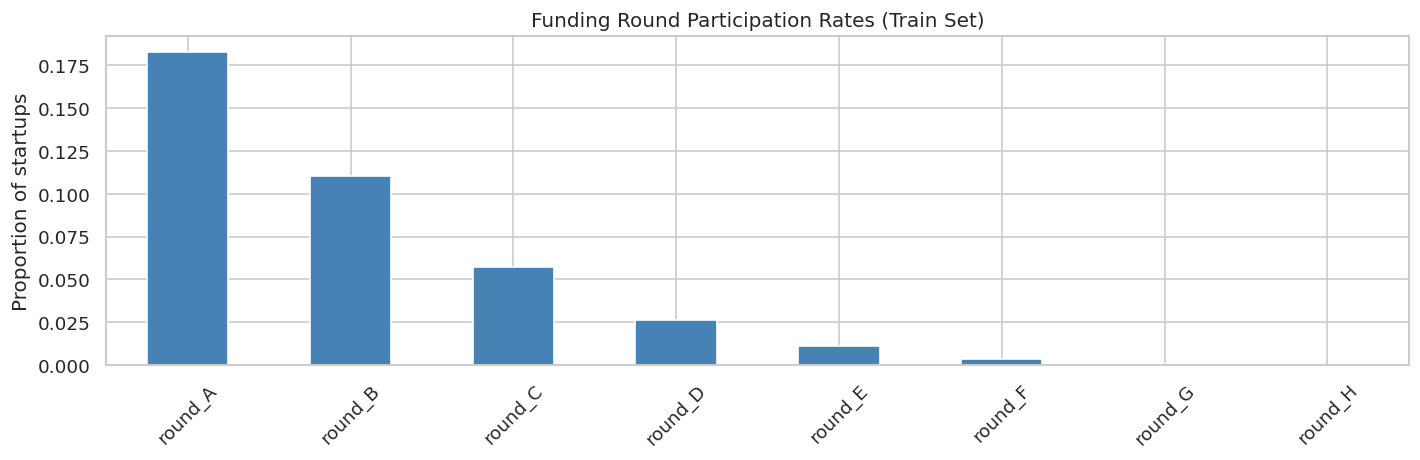

,0
round_A,0.1829
round_B,0.1104
round_C,0.0575
round_D,0.0264
round_E,0.0109
round_F,0.0034
round_G,0.0007
round_H,0.0001


In [29]:
# Participation rates per round in the training set
participation = train[ROUND_COLS].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
participation.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Funding Round Participation Rates (Train Set)')
ax.set_ylabel('Proportion of startups')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

participation

## 4. Target Encoding for `country_code` and `market`

We create **two target-encoded features** for each categorical column:

| New column | Meaning |
|---|---|
| `{col}_enc_acquired` | Proportion of startups in that group with `status_code == 2` (acquired) |
| `{col}_enc_closed`   | Proportion of startups in that group with `status_code == 0` (closed) |

**Encoding is fit and applied on the training set only.**

In [30]:
CAT_COLS = ['country_code', 'market']

# Status code reference
STATUS_ACQUIRED = 2
STATUS_CLOSED   = 0

# Store encoding maps — can be reused to apply to val/test later
encoding_maps = {}  # {col: {'acquired': Series, 'closed': Series}}

# Global fallback values (overall training proportions)
global_acquired = (train['status_code'] == STATUS_ACQUIRED).mean()
global_closed   = (train['status_code'] == STATUS_CLOSED).mean()

print(f'Global acquired rate: {global_acquired:.4f}')
print(f'Global closed rate  : {global_closed:.4f}')

Global acquired rate: 0.0767
Global closed rate  : 0.0541


In [31]:
def compute_target_encoding(df, col, status_acquired=2, status_closed=0):
    """
    Compute per-category proportions for acquired and closed statuses.
    Returns two Series indexed by category value.
    """
    grouped = df.groupby(col)['status_code']
    enc_acquired = grouped.apply(lambda x: (x == status_acquired).mean())
    enc_closed   = grouped.apply(lambda x: (x == status_closed).mean())
    return enc_acquired, enc_closed


def apply_target_encoding(df, col, enc_acquired, enc_closed,
                           fallback_acquired, fallback_closed):
    """
    Map precomputed encoding onto a dataframe split.
    Unknown categories receive the fallback (global training mean).
    """
    df = df.copy()
    df[f'{col}_enc_acquired'] = (
        df[col].map(enc_acquired).fillna(fallback_acquired)
    )
    df[f'{col}_enc_closed'] = (
        df[col].map(enc_closed).fillna(fallback_closed)
    )
    return df


# Fit and apply on train only
for col in CAT_COLS:
    enc_acq, enc_clo = compute_target_encoding(train, col)
    encoding_maps[col] = {'acquired': enc_acq, 'closed': enc_clo}

    train = apply_target_encoding(train, col, enc_acq, enc_clo,
                                   global_acquired, global_closed)

    print(f'\n{col} — encoding map (acquired | closed):')
    summary = pd.DataFrame({
        'acquired_rate': enc_acq,
        'closed_rate'  : enc_clo,
        'n'            : train[col].value_counts()
    }).sort_values('acquired_rate', ascending=False)
    print(summary.to_string())


country_code — encoding map (acquired | closed):
              acquired_rate  closed_rate      n
country_code                                   
USA                  0.0986       0.0519  19717
ISR                  0.0782       0.0658    486
DEU                  0.0755       0.0493    649
CAN                  0.0752       0.0447    917
FRA                  0.0603       0.0537    614
ESP                  0.0538       0.0645    372
GBR                  0.0522       0.0610   1819
SWE                  0.0404       0.0538    223
Other                0.0389       0.0623   7429
IND                  0.0235       0.0419    596
CHN                  0.0231       0.0289    864

market — encoding map (acquired | closed):
                       acquired_rate  closed_rate      n
market                                                  
 Semiconductors               0.1836       0.0706    354
 Security                     0.1740       0.0525    362
 Enterprise Software          0.1622       0.0439    8

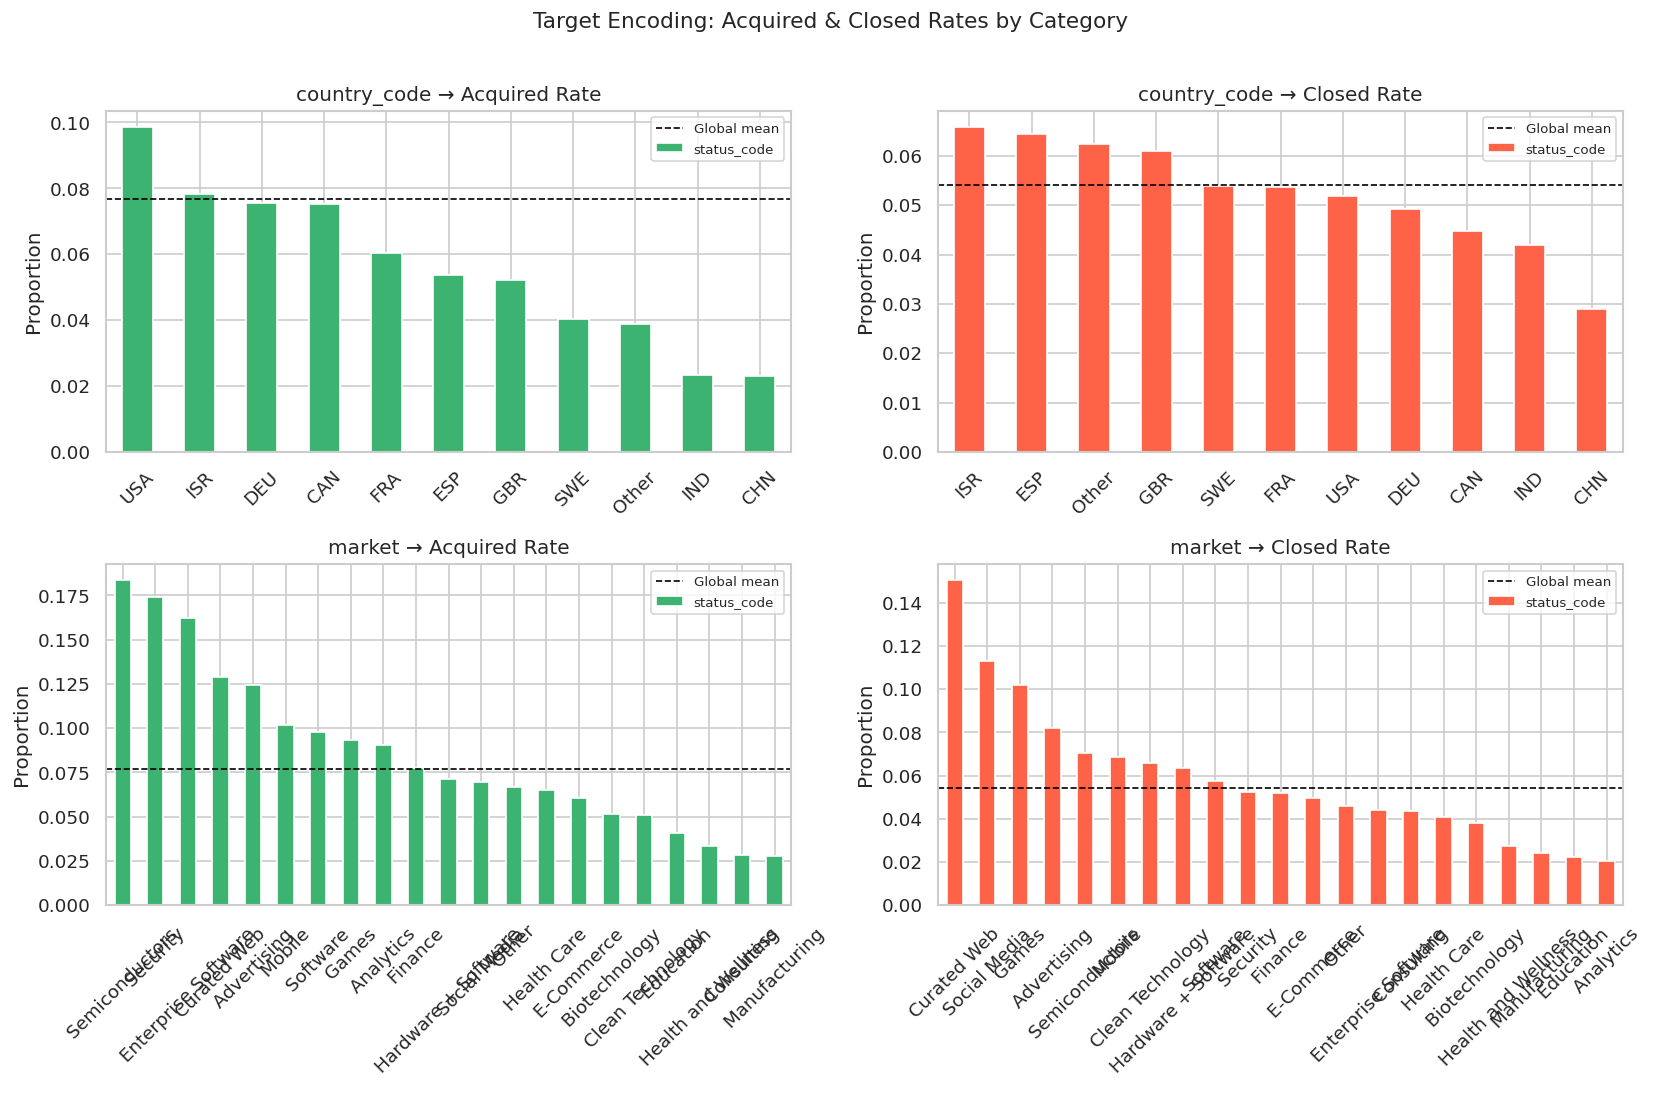

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, col in enumerate(CAT_COLS):
    for col_idx, (status_key, label, color) in enumerate([
        ('acquired', 'Acquired Rate', 'mediumseagreen'),
        ('closed',   'Closed Rate',   'tomato')
    ]):
        ax = axes[row_idx][col_idx]
        data = encoding_maps[col][status_key].sort_values(ascending=False)
        data.plot(kind='bar', ax=ax, color=color, edgecolor='white')
        ax.set_title(f'{col} → {label}')
        ax.set_ylabel('Proportion')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        ax.axhline(global_acquired if status_key == 'acquired' else global_closed,
                   color='black', linestyle='--', linewidth=1, label='Global mean')
        ax.legend(fontsize=8)

plt.suptitle('Target Encoding: Acquired & Closed Rates by Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# Also drop status_label (redundant with status_code) and any date strings
COLS_TO_DROP = CAT_COLS + ['status_label', 'first_funding_at', 'last_funding_at']

def drop_if_exists(df, cols):
    return df.drop(columns=[c for c in cols if c in df.columns])

train = drop_if_exists(train, COLS_TO_DROP)

print('Dropped:', COLS_TO_DROP)
print(f'\nFinal shape — train: {train.shape}')
print('\nFinal columns:')
print(train.columns.tolist())

Dropped: ['country_code', 'market', 'status_label', 'first_funding_at', 'last_funding_at']

Final shape — train: (33686, 31)

Final columns:
['funding_total_usd', 'funding_rounds', 'founded_month', 'founded_quarter', 'founded_year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H', 'status_code', 'country_code_enc_acquired', 'country_code_enc_closed', 'market_enc_acquired', 'market_enc_closed']


In [34]:
# Check no NaNs were introduced
null_counts = train.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
if cols_with_nulls.empty:
    print('Train: no unexpected NaNs ✓')
else:
    print('Train: columns with NaNs:')
    print(cols_with_nulls)

# Check no NaNs were introduced
null_counts = train.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
if cols_with_nulls.empty:
    print('Train: no unexpected NaNs ✓')
else:
    print('Train: columns with NaNs:')
    print(cols_with_nulls)

# Quick value ranges for the new encoded columns
enc_cols = [c for c in train.columns if '_enc_' in c]
train[enc_cols].describe().round(4)

# Correlation of new encoded features with the target
corr = train[enc_cols + ['status_code']].corr()['status_code'].drop('status_code')
print('Correlation with status_code:')
print(corr.sort_values(ascending=False).to_string())

Train: columns with NaNs:
funding_total_usd    5842
founded_month        7405
founded_quarter      7405
founded_year         7405
dtype: int64
Train: columns with NaNs:
funding_total_usd    5842
founded_month        7405
founded_quarter      7405
founded_year         7405
dtype: int64
Correlation with status_code:
country_code_enc_acquired    0.0830
market_enc_acquired          0.0484
market_enc_closed           -0.0268
country_code_enc_closed     -0.0438


In [35]:
# Save to CSV
train.to_csv('train_encoded.csv', index=False)
print(f'Saved: train_encoded.csv  — {train.shape[0]:,} rows × {train.shape[1]} columns')

# Expose as named DataFrame for downstream use
train_encoded = train.copy()
print(f'\ntrain_encoded DataFrame ready — {train_encoded.shape[0]:,} rows × {train_encoded.shape[1]} columns')
train_encoded

Saved: train_encoded.csv  — 33,686 rows × 31 columns

train_encoded DataFrame ready — 33,686 rows × 31 columns


,funding_total_usd,funding_rounds,founded_month,founded_quarter,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,status_code,country_code_enc_acquired,country_code_enc_closed,market_enc_acquired,market_enc_closed
1398,325999.0000,1.0000,1.0000,1.0000,2012.0000,0.0000,325999.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,1,0.0986,0.0519,0.0976,0.0573
40838,2800000.0000,2.0000,3.0000,1.0000,2011.0000,500000.0000,2300000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0,0,0,0,0,1,0.0389,0.0623,0.0666,0.0460
750,100000.0000,1.0000,5.0000,2.0000,2013.0000,0.0000,0.0000,0.0000,0.0000,100000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,1,0.0389,0.0623,0.0666,0.0460
22983,10550000.0000,2.0000,1.0000,1.0000,2012.0000,1750000.0000,8800000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0,0,0,0,0,1,0.0986,0.0519,0.0603,0.0497
42473,19300000.0000,3.0000,5.0000,2.0000,2010.0000,0.0000,19300000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,1,0,0,0,0,0,0,1,0.0986,0.0519,0.0666,0.0460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,4545754.0000,1.0000,1.0000,1.0000,2003.0000,0.0000,4545754.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,1,0.0522,0.0610,0.0651,0.0410
22805,1000000.0000,1.0000,1.0000,1.0000,1999.0000,0.0000,1000000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0,0,0,0,0,1,0.0389,0.0623,0.0933,0.1021
43068,500000.0000,1.0000,8.0000,3.0000,2012.0000,500000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,1,0.0389,0.0623,0.0905,0.0204
13916,150000.0000,2.0000,2.0000,1.0000,2008.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,150000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,1,0.0986,0.0519,0.0666,0.0460
